Final Practical - 05/06/2026 - edwgol5635

In [1]:
categorical_cols=['Ship Mode','Segment','Country/Reigon','Category','Sub-Category']

In [2]:
import simpy
import random
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

random.seed(42)

In [3]:
def run_simulation(num_employees, interarrival_time=3):
    env = simpy.Environment()
    counter = simpy.Resource(env, capacity=num_employees)

    wait_times = []
    arrival_times = []

    def customer(env, name):
        arrival = env.now
        arrival_times.append(arrival)

        with counter.request() as request:
            yield request

            wait = env.now - arrival
            wait_times.append(wait)

            service_time = random.uniform(3, 7)
            yield env.timeout(service_time)

    def arrivals(env):
        for i in range(50):
            yield env.timeout(interarrival_time)
            env.process(customer(env, f"Customer {i}"))

    env.process(arrivals(env))
    env.run(until=480)

    return arrival_times, wait_times

   


In [4]:
data = []

for employees in [1, 2, 3]:
    arrivals, waits = run_simulation(employees)

    for i in range(len(waits)):
        data.append({
            "employees": employees,
            "arrival_time": arrivals[i],
            "wait_time": waits[i],
            "interarrival_time": 3
        })

df = pd.DataFrame(data)
df.head()


,employees,arrival_time,wait_time,interarrival_time
0,1,3,0.000000,3
1,1,6,2.557707,3
2,1,9,2.657750,3
3,1,12,3.757867,3
4,1,15,4.650710,3


In [5]:
avg_wait = df.groupby("employees")["wait_time"].mean()
print(avg_wait)


employees
1    43.430571
2     0.155174
3     0.000000
Name: wait_time, dtype: float64


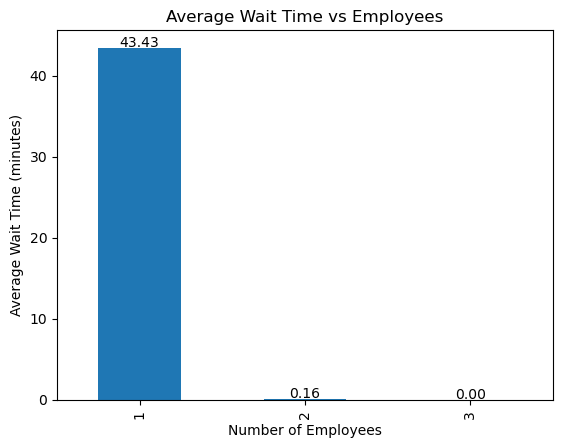

In [6]:
ax = avg_wait.plot(kind='bar')

for i, v in enumerate(avg_wait):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center')

plt.title("Average Wait Time vs Employees")
plt.xlabel("Number of Employees")
plt.ylabel("Average Wait Time (minutes)")

plt.show()


In [7]:
X = df[['employees', 'interarrival_time']]
y = df['wait_time']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 238.23951631129074
R2: 0.5806639981793941


In [9]:
param_grid = {'fit_intercept': [True, False]}

grid = GridSearchCV(LinearRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("R2:", r2_score(y_test, y_pred_best))

Best Parameters: {'fit_intercept': True}
MSE: 238.23951631129074
R2: 0.5806639981793941


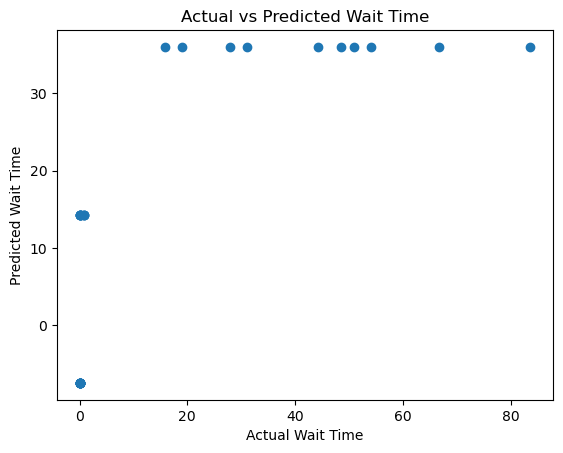

In [10]:
plt.scatter(y_test, y_pred_best)

plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.title("Actual vs Predicted Wait Time")

plt.show()


In [11]:
data_fast = []

for employees in [1, 2, 3]:
    arrivals, waits = run_simulation(employees, interarrival_time=2)

    for w in waits:
        data_fast.append({
            "employees": employees,
            "wait_time": w,
            "scenario": "High Traffic"
        })

df_fast = pd.DataFrame(data_fast)

df["scenario"] = "Normal"

combined = pd.concat([df, df_fast])

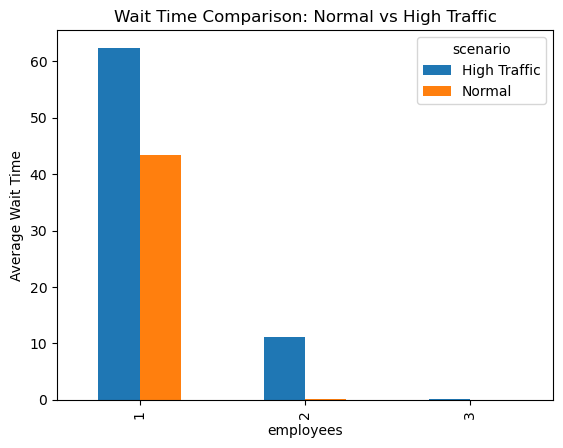

In [12]:
comparison = combined.groupby(['employees', 'scenario'])['wait_time'].mean().unstack()

comparison.plot(kind='bar')

plt.title("Wait Time Comparison: Normal vs High Traffic")
plt.ylabel("Average Wait Time")

plt.show()
